# ASSIGNMENT 10 — Comparing GAN and VAE Using My Experimental Results

**Name:** Dipin Roka  
**Assignment:** 10 — Comparing GAN and VAE Using Experimental Results

## Objective

In this assignment, I compare the results of the GAN from Assignment 4 and the VAE from Assignment 8.

I am using the outputs and settings from my own previous experiments. The comparison is based on what I observed from the generated images, training behaviour and latent-space experiment instead of only describing the models theoretically.

The main things I compare are image sharpness, diversity, realism, training stability, ease of controlling the output, risk of mode collapse and typical applications.

## 1. Models Used in My Previous Assignments

### Assignment 4 — DCGAN

In Assignment 4, I trained a **DCGAN on the Fashion-MNIST dataset**.

My experiment used:

- Fashion-MNIST
- 60,000 training images
- Original images resized from 28×28 to **32×32**
- Noise vector size = **64**
- Batch size = **128**
- Training = **30 epochs**
- Learning rate = **0.0002**
- Adam optimizer
- Generator output uses `Tanh`

The generator takes random noise and gradually converts it into a 32×32 grayscale clothing image. The discriminator tries to identify whether an image is real or generated.

### Assignment 8 — VAE

In Assignment 8, I built a **Variational Autoencoder on the MNIST handwritten digit dataset**.

My experiment used:

- MNIST
- 60,000 training images
- 28×28 grayscale images
- **2-dimensional latent space**
- Batch size = **128**
- Training = **20 epochs**
- Learning rate = **0.001**
- Adam optimizer

The VAE objective combines reconstruction loss with KL-divergence loss. The 2D latent space was useful because I could directly visualise how different digit classes were organised.

## 2. Libraries

I use PyTorch for the DCGAN and TensorFlow/Keras for the VAE, matching the frameworks from my previous assignments.

I also use Matplotlib and Pandas for displaying the outputs and preparing the comparison.

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("TensorFlow:", tf.__version__)
print("PyTorch device:", device)

PyTorch: 2.11.0+cu130
TensorFlow: 2.21.0
PyTorch device: cuda


## 3. Recreating My Assignment 4 DCGAN Setup

I am keeping the same important settings from my Assignment 4 notebook.

One important detail is that my Fashion-MNIST images were resized to **32×32** before being given to the GAN. I also used a **64-dimensional noise vector**, so I keep both of these values unchanged here.

In [ ]:
NOISE_SIZE = 64
IMAGE_SIZE = 32
BATCH_SIZE = 128
GAN_EPOCHS = 30
GAN_LR = 0.0002
SAVE_EVERY = 5

gan_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

gan_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=gan_transform
)

gan_loader = DataLoader(
    gan_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Fashion-MNIST images:", len(gan_dataset))
print("Image size used by GAN:", IMAGE_SIZE, "x", IMAGE_SIZE)
print("Noise size:", NOISE_SIZE)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.86MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.0MB/s]

Fashion-MNIST images: 60000
Image size used by GAN: 32 x 32
Noise size: 64


## 4. Generator and Discriminator

The generator in my Assignment 4 model grows the image step by step:

**noise → 4×4 → 8×8 → 16×16 → 32×32**

The discriminator works in the opposite direction and ends with one real/fake decision.

I kept the same architecture here so that the samples are generated from the same kind of model that I used previously.

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(NOISE_SIZE, 128, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, noise):
        return self.net(noise)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, image):
        return self.net(image).view(-1)

## 5. Preparing the GAN Training

I use Binary Cross Entropy because the discriminator is making a binary real/fake decision.

I also use the same Adam learning rate and beta values from Assignment 4. Fixed noise is used for the final eight samples so that the generated images are easy to reproduce.

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G.apply(weights_init)
D.apply(weights_init)

loss_function = nn.BCELoss()

optimizer_G = optim.Adam(
    G.parameters(),
    lr=GAN_LR,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    D.parameters(),
    lr=GAN_LR,
    betas=(0.5, 0.999)
)

fixed_noise = torch.randn(
    8, NOISE_SIZE, 1, 1, device=device
)

print("GAN models and optimizers are ready.")

GAN models and optimizers are ready.


## 6. Training the DCGAN

For each batch, I first update the discriminator using real and generated images.

Then I update the generator and try to make the discriminator classify its generated images as real.

I store the average generator and discriminator losses for each epoch. The losses are also useful when I discuss training stability.

In [ ]:
g_losses = []
d_losses = []

for epoch in range(1, GAN_EPOCHS + 1):
    total_g_loss = 0.0
    total_d_loss = 0.0

    for real_images, _ in gan_loader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # Train Discriminator
        optimizer_D.zero_grad()

        prediction_real = D(real_images)
        loss_real = loss_function(prediction_real, real_labels)

        noise = torch.randn(
            batch_size, NOISE_SIZE, 1, 1, device=device
        )
        fake_images = G(noise)

        prediction_fake = D(fake_images.detach())
        loss_fake = loss_function(prediction_fake, fake_labels)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()

        prediction = D(fake_images)
        g_loss = loss_function(prediction, real_labels)

        g_loss.backward()
        optimizer_G.step()

        total_d_loss += d_loss.item()
        total_g_loss += g_loss.item()

    avg_d = total_d_loss / len(gan_loader)
    avg_g = total_g_loss / len(gan_loader)

    d_losses.append(avg_d)
    g_losses.append(avg_g)

    print(
        f"Epoch {epoch:02d}/{GAN_EPOCHS} | "
        f"D loss: {avg_d:.3f} | G loss: {avg_g:.3f}"
    )

print("GAN training complete.")

Epoch 01/30 | D loss: 0.479 | G loss: 2.838
Epoch 02/30 | D loss: 0.830 | G loss: 1.516
Epoch 03/30 | D loss: 0.930 | G loss: 1.349
Epoch 04/30 | D loss: 0.847 | G loss: 1.525
Epoch 05/30 | D loss: 0.694 | G loss: 1.858
Epoch 06/30 | D loss: 0.539 | G loss: 2.199
Epoch 07/30 | D loss: 0.508 | G loss: 2.363
Epoch 08/30 | D loss: 0.487 | G loss: 2.472
Epoch 09/30 | D loss: 0.410 | G loss: 2.745
Epoch 10/30 | D loss: 0.438 | G loss: 2.745
Epoch 11/30 | D loss: 0.359 | G loss: 2.949
Epoch 12/30 | D loss: 0.324 | G loss: 3.271
Epoch 13/30 | D loss: 0.364 | G loss: 3.092
Epoch 14/30 | D loss: 0.264 | G loss: 3.504
Epoch 15/30 | D loss: 0.327 | G loss: 3.334
Epoch 16/30 | D loss: 0.225 | G loss: 3.841
Epoch 17/30 | D loss: 0.409 | G loss: 2.985
Epoch 18/30 | D loss: 0.170 | G loss: 4.096
Epoch 19/30 | D loss: 0.392 | G loss: 3.155
Epoch 20/30 | D loss: 0.278 | G loss: 3.414
Epoch 21/30 | D loss: 0.131 | G loss: 4.417
Epoch 22/30 | D loss: 0.330 | G loss: 3.543
Epoch 23/30 | D loss: 0.272 | G 

## 7. GAN Training Loss

GAN losses do not have to decrease smoothly like a normal supervised-learning loss. The generator and discriminator are competing, so some oscillation is expected.

I use the graph below as one piece of evidence for discussing whether the training remained reasonably stable.

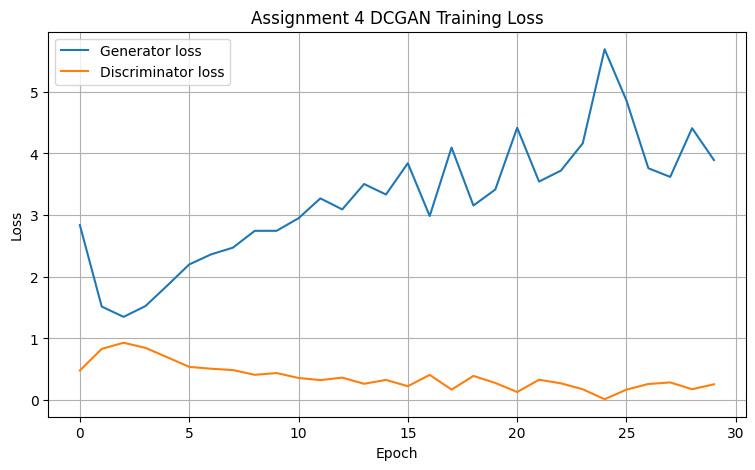

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(g_losses, label="Generator loss")
plt.plot(d_losses, label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Assignment 4 DCGAN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

## 8. Eight Images Generated by My GAN

These are eight final samples generated from the trained DCGAN using fixed noise.

I will use these images for the visual part of the comparison.

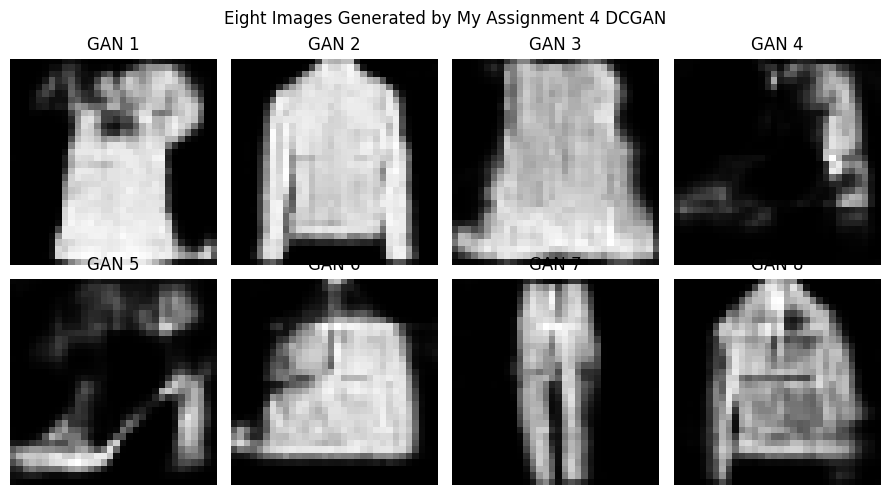

In [ ]:
G.eval()

with torch.no_grad():
    gan_generated = G(fixed_noise).cpu()

G.train()

fig, axes = plt.subplots(2, 4, figsize=(9, 5))

for i, ax in enumerate(axes.flatten()):
    image = (gan_generated[i] + 1) / 2
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"GAN {i+1}")
    ax.axis("off")

plt.suptitle("Eight Images Generated by My Assignment 4 DCGAN")
plt.tight_layout()
plt.show()

## 9. Recreating My Assignment 8 VAE

My Assignment 8 VAE uses a Dense encoder and decoder.

The encoder produces two values for the mean and two values for log variance because the latent representation has exactly two dimensions.

The sampling layer uses these values to produce the latent vector that is passed to the decoder.

In [ ]:
LATENT_DIM = 2
VAE_EPOCHS = 20
VAE_BATCH_SIZE = 128
VAE_LR = 0.001

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))

print("Training shape:", x_train_flat.shape)
print("Testing shape:", x_test_flat.shape)

encoder_inputs = keras.Input(shape=(784,), name="encoder_input")

x = layers.Dense(256, activation="relu", name="encoder_dense_1")(encoder_inputs)
x = layers.Dense(64, activation="relu", name="encoder_dense_2")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)

encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var],
    name="encoder"
)

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

sampling_layer = Sampling()

latent_inputs = keras.Input(
    shape=(LATENT_DIM,),
    name="decoder_input"
)

x = layers.Dense(64, activation="relu", name="decoder_dense_1")(latent_inputs)
x = layers.Dense(256, activation="relu", name="decoder_dense_2")(x)

decoder_outputs = layers.Dense(
    784,
    activation="sigmoid",
    name="decoder_output"
)(x)

decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

print("VAE created with latent dimension:", LATENT_DIM)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 784)
Testing shape: (10000, 784)
VAE created with latent dimension: 2


## 10. Training the VAE

The VAE uses reconstruction loss and KL-divergence together.

Reconstruction loss checks whether the decoded image is close to the input image. KL-divergence keeps the learned latent distribution regularised, which makes the latent space smoother and easier to sample from.

I keep the same 20-epoch training setup from Assignment 8.

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, sampling_layer, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampling_layer = sampling_layer

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def call(self, inputs):
        z_mean, z_log_var = self.encoder(inputs)
        z = self.sampling_layer([z_mean, z_log_var])
        return self.decoder(z)

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(data)
            z = self.sampling_layer([z_mean, z_log_var])

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                )
            ) * 784

            kl_loss = -0.5 * (
                1 + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var)
            )

            kl_loss = tf.reduce_mean(
                tf.reduce_sum(kl_loss, axis=1)
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }


vae = VAE(
    encoder,
    decoder,
    sampling_layer
)

vae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=VAE_LR
    )
)

history = vae.fit(
    x_train_flat,
    epochs=VAE_EPOCHS,
    batch_size=VAE_BATCH_SIZE,
    shuffle=True,
    verbose=1
)

recon_loss_history = history.history["reconstruction_loss"]
kl_loss_history = history.history["kl_loss"]
total_loss_history = history.history["loss"]

print("VAE training complete.")
print("Final reconstruction loss:", recon_loss_history[-1])
print("Final KL loss:", kl_loss_history[-1])
print("Final total loss:", total_loss_history[-1])

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - kl_loss: 5.2581 - loss: 199.1135 - reconstruction_loss: 193.8556
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.6270 - loss: 171.7821 - reconstruction_loss: 167.1551
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.9444 - loss: 165.3156 - reconstruction_loss: 160.3713
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.1232 - loss: 161.6700 - reconstruction_loss: 156.5468
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.3186 - loss: 158.7636 - reconstruction_loss: 153.4452
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.4984 - loss: 156.2977 - reconstruction_loss: 150.7994
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.6437 - loss: 154.3398 - reconstruction_loss: 148.6960
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.7727 - loss: 152.7634 - reconstruction_loss: 146.9907
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/s

## 11. VAE Loss Curves

I plot the reconstruction and KL-divergence losses separately because both are important parts of the VAE objective.

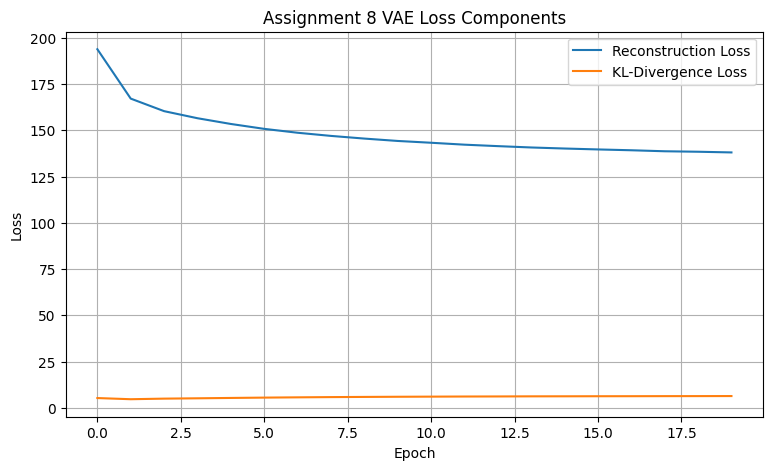

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(
    recon_loss_history,
    label="Reconstruction Loss"
)
plt.plot(
    kl_loss_history,
    label="KL-Divergence Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Assignment 8 VAE Loss Components")
plt.legend()
plt.grid(True)
plt.show()

## 12. My VAE Latent Space

A major part of Assignment 8 was visualising the learned 2D latent space.

I use the encoder to obtain the mean latent representation of the test set and plot the points according to their digit labels. This gives a direct visual idea of how the VAE organised different digits.

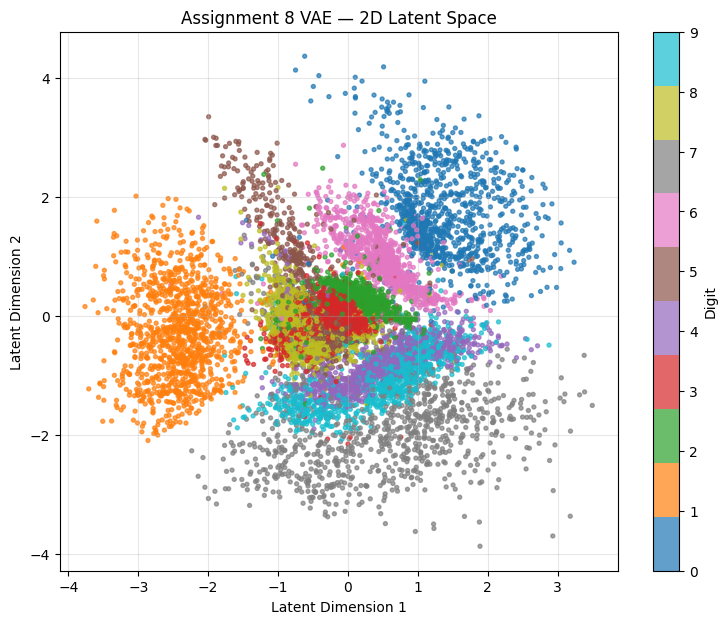

In [ ]:
z_mean_test, z_log_var_test = encoder.predict(
    x_test_flat,
    batch_size=VAE_BATCH_SIZE,
    verbose=0
)

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.colorbar(
    scatter,
    ticks=range(10),
    label="Digit"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Assignment 8 VAE — 2D Latent Space")
plt.grid(True, alpha=0.3)
plt.show()

## 13. Eight Images Generated by My VAE

I now choose eight points from the 2D latent space and pass them through the decoder.

The main benefit I notice here is that the output can be explored directly by changing the latent coordinates.

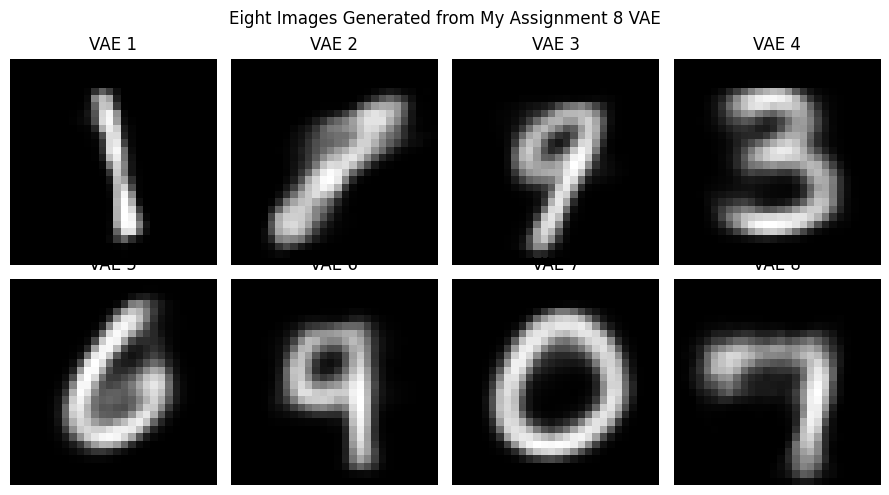

In [ ]:
vae_latent_points = np.array([
    [-2.5, -2.0],
    [-1.5,  1.0],
    [-0.5, -1.5],
    [ 0.0,  0.0],
    [ 0.5,  1.5],
    [ 1.0, -0.5],
    [ 1.8,  1.5],
    [ 2.5, -1.0]
], dtype=np.float32)

vae_generated = decoder.predict(
    vae_latent_points,
    verbose=0
).reshape(8, 28, 28)

fig, axes = plt.subplots(2, 4, figsize=(9, 5))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(vae_generated[i], cmap="gray")
    ax.set_title(f"VAE {i+1}")
    ax.axis("off")

plt.suptitle("Eight Images Generated from My Assignment 8 VAE")
plt.tight_layout()
plt.show()

## 14. Simple Supporting Measurements

The assignment is mainly a visual comparison, so I use these values only as supporting measurements.

I calculate:

- a simple sharpness proxy using local pixel changes
- a simple diversity proxy using average pairwise pixel differences

These values should not be treated as a complete image-quality metric.

In [ ]:
def sharpness_proxy(images):
    values = []

    for image in images:
        dx = np.diff(image, axis=1)
        dy = np.diff(image, axis=0)

        values.append(
            np.mean(dx ** 2) + np.mean(dy ** 2)
        )

    return float(np.mean(values))


def diversity_proxy(images):
    flat = images.reshape(len(images), -1)
    distances = []

    for i in range(len(flat)):
        for j in range(i + 1, len(flat)):
            distances.append(
                np.mean(np.abs(flat[i] - flat[j]))
            )

    return float(np.mean(distances))


gan_images_for_metrics = (
    (gan_generated.numpy() + 1) / 2
).astype("float32")

# Resize GAN samples to 28x28 only for this rough pixel-difference proxy,
# because the GAN outputs are 32x32 while the VAE outputs are 28x28.
gan_images_for_metrics = torch.nn.functional.interpolate(
    torch.tensor(gan_images_for_metrics),
    size=(28, 28),
    mode="bilinear",
    align_corners=False
).numpy()

vae_images_for_metrics = vae_generated.astype("float32")

metrics_table = pd.DataFrame({
    "Model": ["GAN", "VAE"],
    "Sharpness proxy": [
        sharpness_proxy(gan_images_for_metrics),
        sharpness_proxy(vae_images_for_metrics)
    ],
    "Diversity proxy": [
        diversity_proxy(gan_images_for_metrics),
        diversity_proxy(vae_images_for_metrics)
    ]
})

display(metrics_table)

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


,Model,Sharpness proxy,Diversity proxy
0,GAN,NaN,0.262410
1,VAE,0.020773,0.142153


## 15. Comparison Table

There is one important limitation in this comparison: my Assignment 4 GAN was trained on **Fashion-MNIST**, while my Assignment 8 VAE was trained on **MNIST**.

Because the datasets are different, I use the generated images mainly to understand the practical behaviour of the two model types. I do not treat the raw sharpness/diversity numbers as a fair head-to-head benchmark across the two datasets.

In [ ]:
comparison_table = pd.DataFrame({
    "Criterion": [
        "Image sharpness",
        "Diversity",
        "Realism",
        "Training stability",
        "Ease of controlling the output",
        "Risk of mode collapse",
        "Typical applications"
    ],

    "GAN — My Observation": [
        "Sharper clothing outlines and stronger visual detail",
        "Good variation, but similar outputs can sometimes appear",
        "Generally stronger visual realism in the generated clothing samples",
        "Training is more sensitive because G and D compete with each other",
        "Moderate; the main control comes from changing the noise vector",
        "Higher risk",
        "Synthetic image generation and image synthesis"
    ],

    "VAE — My Observation": [
        "Smoother and generally softer images",
        "Good variation across the latent space",
        "Good overall digit structure, but usually less sharp",
        "More straightforward and stable to optimise",
        "High because the 2D latent coordinates can be explored directly",
        "Low compared with GAN",
        "Anomaly detection, reconstruction and representation learning"
    ]
})

display(comparison_table)

,Criterion,GAN — My Observation,VAE — My Observation
0,Image sharpness,Sharper clothing outlines and stronger visual ...,Smoother and generally softer images
1,Diversity,"Good variation, but similar outputs can someti...",Good variation across the latent space
2,Realism,Generally stronger visual realism in the gener...,"Good overall digit structure, but usually less..."
3,Training stability,Training is more sensitive because G and D com...,More straightforward and stable to optimise
4,Ease of controlling the output,Moderate; the main control comes from changing...,High because the 2D latent coordinates can be ...
5,Risk of mode collapse,Higher risk,Low compared with GAN
6,Typical applications,Synthetic image generation and image synthesis,"Anomaly detection, reconstruction and represen..."


## 16. Final Verdict

### 1. Which model would I prefer for generating synthetic training data?

**I would prefer the GAN.**

In my Assignment 4 results, the DCGAN produced sharper-looking synthetic images. For a task where realistic synthetic images are the main goal, I would choose the GAN.

### 2. Which model would I prefer for anomaly detection?

**I would prefer the VAE.**

The VAE learns a structured latent representation and reconstructs the input. This makes reconstruction error and latent-space behaviour useful when trying to identify unusual samples.

### 3. Why?

From my experiments, I found that the two models are useful for different purposes.

The GAN is stronger when the main priority is image sharpness and visual realism, but its adversarial training can be harder to stabilise and it can suffer from mode collapse.

The VAE produces smoother outputs, but its latent space is structured and directly interpretable in my 2D experiment. It is therefore more suitable for reconstruction-based analysis and anomaly detection.

**My final choice:**

- **Synthetic training data → GAN**
- **Anomaly detection → VAE**

## 17. Conclusion

This experiment helped me compare GAN and VAE from the outputs of my own previous assignments.

The DCGAN from Assignment 4 was better for producing sharper synthetic images, while the VAE from Assignment 8 gave me a clearer and more structured latent representation.

I understood that choosing between GAN and VAE depends on the actual application. For realistic image generation, I would choose the GAN. For anomaly detection, reconstruction and latent-space analysis, I would choose the VAE.